# Wine Classification Using Machine Learning
## Objective
The objective of this analysis is to apply machine learning classification techniques to the Wine dataset in order to classify wines into their respective classes based on their chemical properties.
The dataset contains 178 wine samples belonging to three different classes. Each sample is described using 13 chemical properties such as alcohol content, malic acid, flavanoids, colour intensity and proline.

This notebook will:
1. Explore and understand the Wine dataset.
2. Preprocess the data for machine learning.
3. Train two classification algorithms:
   - Decision Tree Classifier
   - Support Vector Machine (SVM)
4. Evaluate the models using accuracy, precision, recall, F1-score, confusion matrices and ROC curves.
5. Compare the performance of the models.
6. Investigate which chemical properties are most important for wine classification.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [71]:
# loading dataset
df = pd.read_csv("wine.csv")
df.head(10)

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,1,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


# Data Exploration

Load the Wine dataset into your notebook
Explore the dataset by checking its basic statistics and visualizing the data, such as histograms, scatter plots, or pair plots.

In [72]:
# Data dimension

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 178
Number of columns: 14


In [73]:
# columns names & Data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [74]:
# chwcking for missing values
missing_values = df.isnull().sum()

print("Missing values per column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values per column:
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

Total missing values: 0


In [75]:
# duplicates
duplicates = df.duplicated().sum()
print("Number of duplicated rows:", duplicates)

Number of duplicated rows: 0


In [76]:
# Descriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Wine,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic.acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid.phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


The descriptive statistics show that the chemical variables are measured on substantially different scales.

For example, some variables contain relatively small decimal values, while variables such as `Proline` and `Mg` have considerably larger numerical values.

This difference in scale is particularly important for the Support Vector Machine because distance and the relative magnitude of features can influence the model. Standardisation will therefore be applied during preprocessing.

# target variable
The target variable contains three wine classes. Examining the class distribution is important because severe class imbalance can cause a classifier to favour classes containing more observations.

The classes in this dataset are reasonably represented, although their frequencies are not exactly equal. Stratified sampling will therefore be used when splitting the dataset to preserve approximately the same class proportions in the training and testing datasets.

Wine class distribution:
Wine
1    59
2    71
3    48
Name: count, dtype: int64


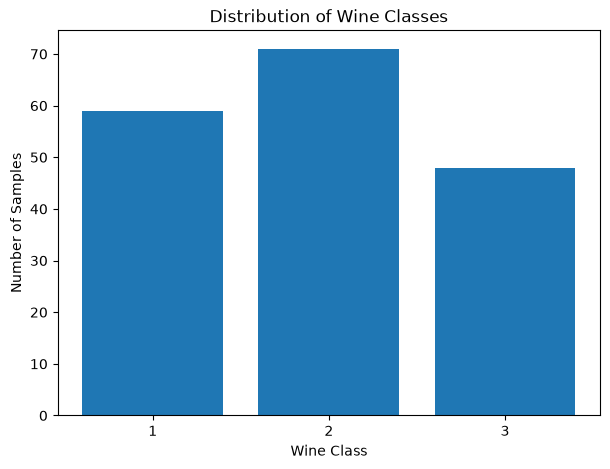

In [77]:
# Examining the Target Variable
class_counts = df["Wine"].value_counts().sort_index()

print("Wine class distribution:")
print(class_counts)

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.title("Distribution of Wine Classes")

plt.show()

# Histogram
The histograms illustrate the distributions of the 13 chemical properties.

The variables have different ranges, distributions and levels of spread. Some variables appear approximately symmetric while others show skewness. The substantial differences in scale further support the use of feature standardisation for the SVM model.

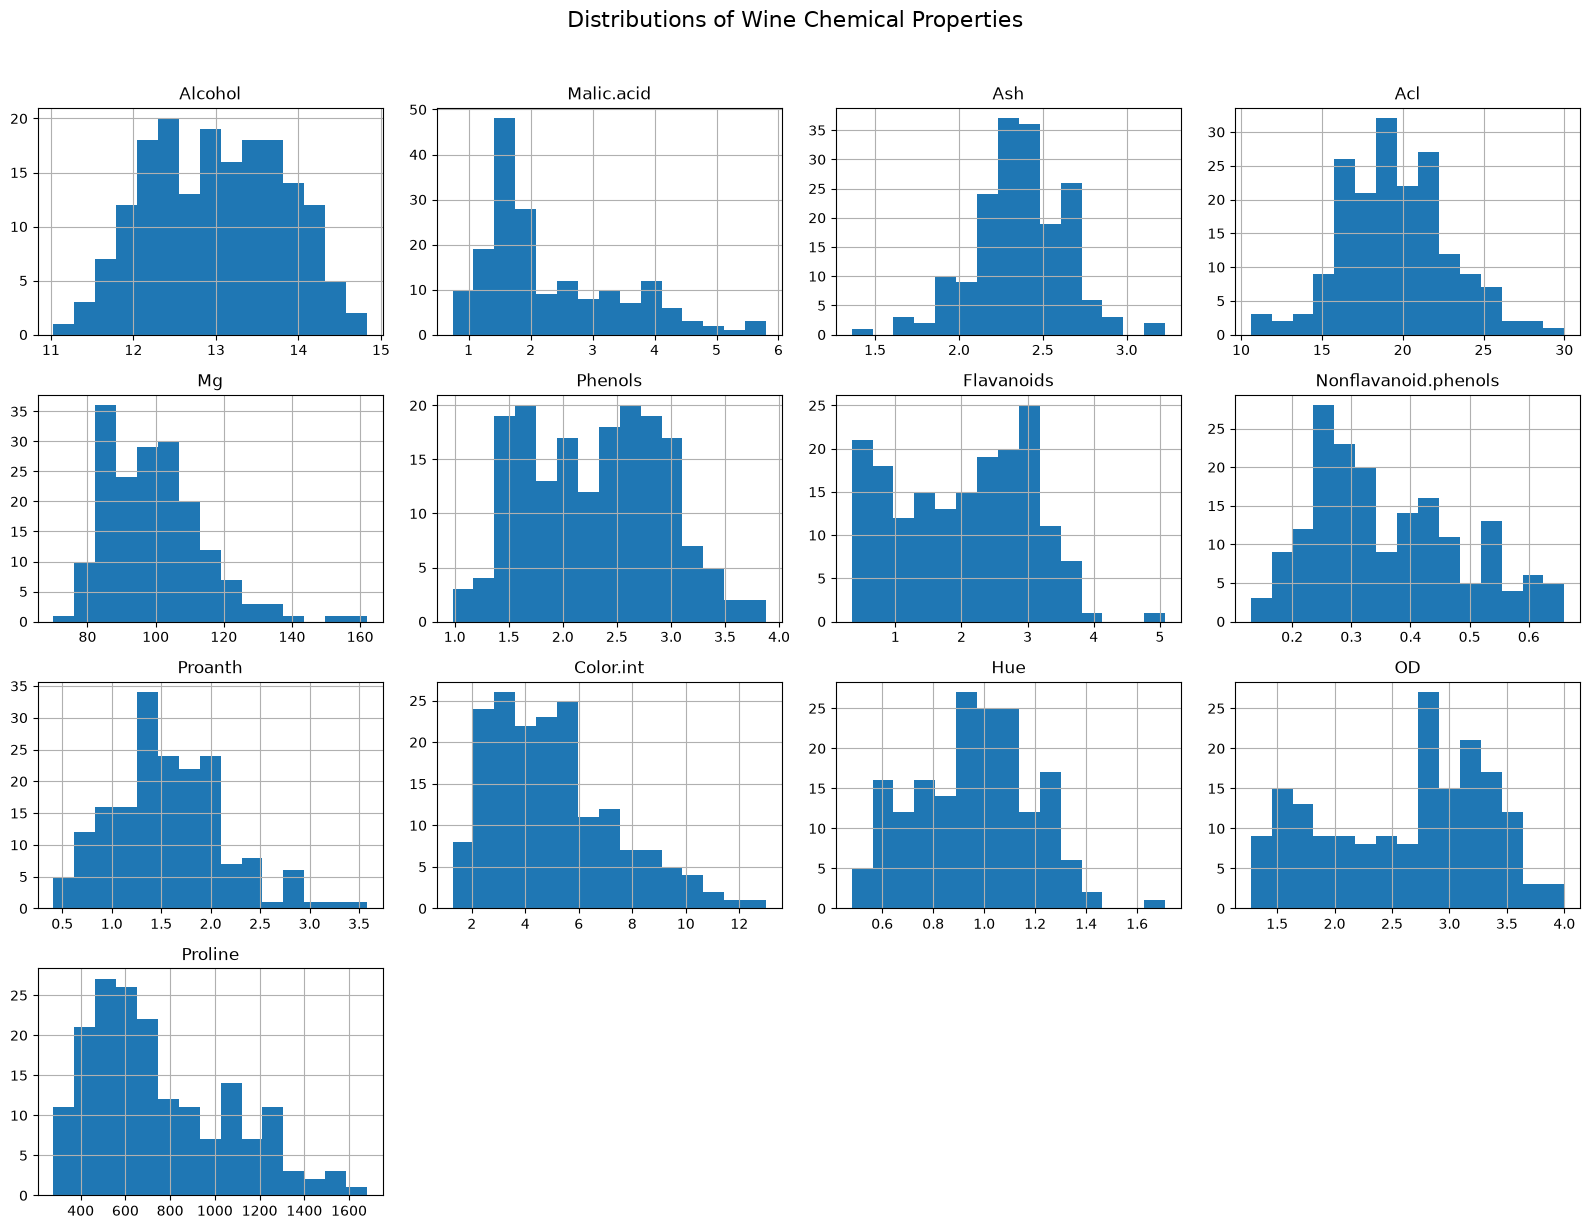

In [78]:
features = df.drop(columns="Wine")

features.hist(figsize=(16, 12), bins=15)

plt.suptitle(
    "Distributions of Wine Chemical Properties",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

The correlation analysis provides an initial indication of relationships between the chemical properties and the wine class.

However, correlation alone should not be interpreted as feature importance. The target variable consists of class labels, and machine learning models may identify non-linear relationships or interactions between variables that simple correlation does not capture.

Feature importance will therefore be investigated later using the trained classifiers.

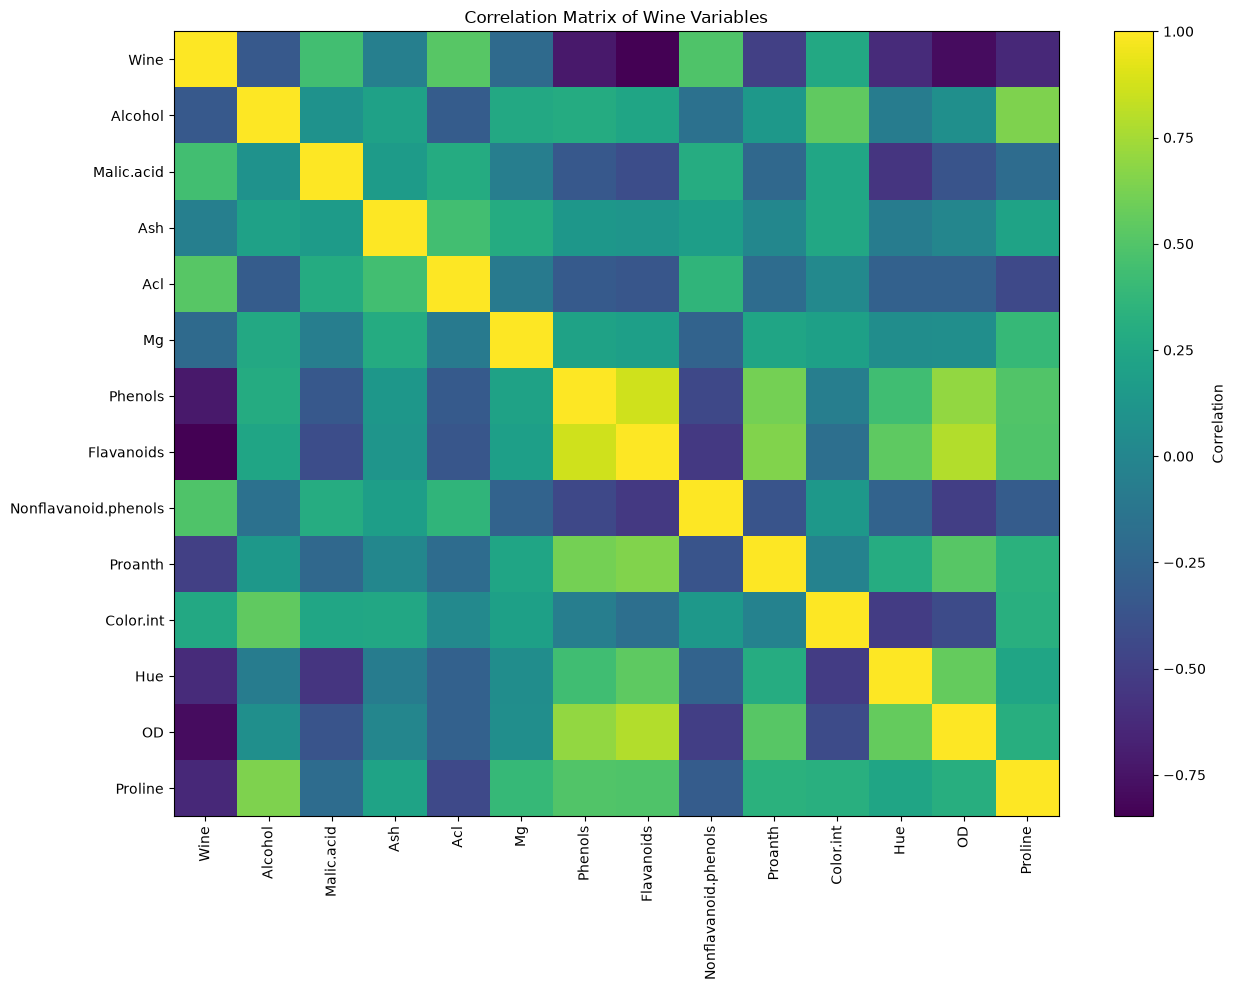

In [79]:
# Strongest Correlations with Wine Class
correlation_matrix = df.corr()

plt.figure(figsize=(13, 10))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Wine Variables")
plt.tight_layout()
plt.show()

# Data Preprocessing
scaling the features, and splitting the data into training and testing sets.

In [80]:
# separating features and target
X = df.drop(columns="Wine")
y = df["Wine"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (178, 13)
Target shape: (178,)


## Train-Test Split

Use 80% training and 20% testing.
The dataset was divided into training and testing subsets using an 80:20 split.

Stratified sampling was used so that the proportions of the three wine classes were approximately preserved in both datasets.

A `random_state` of 42 was specified to make the results reproducible.

The testing dataset was kept separate from model training so that model performance could be evaluated on previously unseen observations.

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training samples: 142
Testing samples: 36

Training class distribution:
Wine
1    47
2    57
3    38
Name: count, dtype: int64

Testing class distribution:
Wine
1    12
2    14
3    10
Name: count, dtype: int64


## Feature Scaling
StandardScaler was used to standardise the predictor variables.

The scaler was fitted only on the training dataset and then applied to both the training and testing datasets. This prevents information from the testing dataset from leaking into the training process.

- Standardisation is particularly important for SVM because variables measured on larger numerical scales could otherwise have a disproportionate influence on the model.
- Decision Trees do not require feature scaling because their decisions are based on threshold splits. Therefore, the Decision Tree will be trained using the original unscaled features.

In [82]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


# Model Selection

Two classification algorithms were selected:

### 1. Decision Tree Classifier

A Decision Tree recursively divides the feature space according to feature values that provide useful separation between classes. Decision Trees are easy to interpret and provide built-in feature importance scores.

### 2. Support Vector Machine (SVM)

Support Vector Machines attempt to identify decision boundaries that maximise the separation between classes. An RBF kernel was selected because it allows the classifier to model non-linear relationships between chemical properties.

These algorithms provide a useful comparison because they use fundamentally different approaches to classification.

In [83]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

print("Decision Tree training completed.")

Decision Tree training completed.


In [84]:
#Support Vector Machine (SVM)
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

svm_predictions = svm_model.predict(X_test_scaled)

print("SVM training completed.")

SVM training completed.


#  Model Evaluation

- Accuracy measures the proportion of all test observations that were classified correctly.

- Precision measures how often the model's predictions for a class were correct.

- Recall measures how effectively the classifier identified the observations that actually belonged to each class.

- The F1-score provides a balance between precision and recall.

Because this is a multiclass classification problem, weighted averages were used when summarising precision, recall and F1-score. The full classification reports also provide class-specific results.

In [85]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted"
    )

    print(model_name)
    print("-" * 50)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [86]:
# Decision tree results
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_predictions
)

Decision Tree
--------------------------------------------------
Accuracy:  0.9444
Precision: 0.9514
Recall:    0.9444
F1-score:  0.9450

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.92      0.96        12
           2       0.88      1.00      0.93        14
           3       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [87]:
# SVM results
svm_results = evaluate_model(
    "Support Vector Machine",
    y_test,
    svm_predictions
)

Support Vector Machine
--------------------------------------------------
Accuracy:  0.9722
Precision: 0.9741
Recall:    0.9722
F1-score:  0.9720

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       0.93      1.00      0.97        14
           3       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## confusion matrix
The confusion matrices show the number of correct and incorrect predictions for each wine class.
Values along the main diagonal represent correctly classified wines, while values outside the diagonal represent classification errors.
A model with stronger classification performance should have most observations concentrated along the main diagonal.

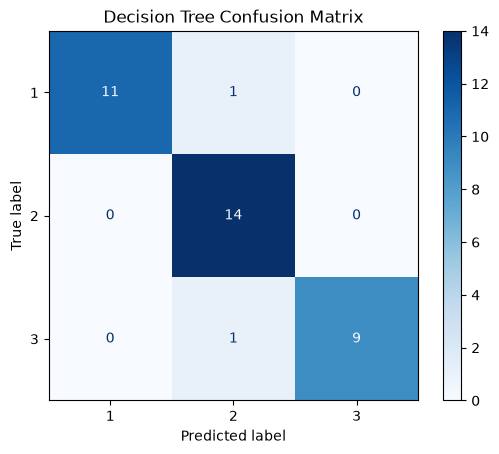

In [88]:
# Decision Tree confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    dt_predictions,
    display_labels=sorted(y.unique()),
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

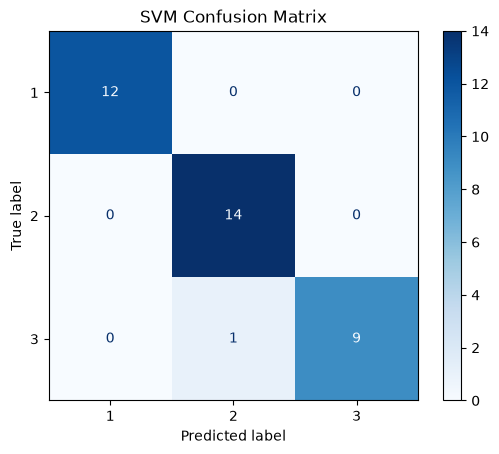

In [89]:
# SVM confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_predictions,
    display_labels=sorted(y.unique()),
    cmap="Blues"
)

plt.title("SVM Confusion Matrix")
plt.show()

## Roc Curves
ROC curves were generated using a One-vs-Rest approach because the target variable contains three classes.
For each wine class, that class is temporarily treated as the positive class while the remaining classes are treated as negative.
The Area Under the Curve (AUC) summarises the model's ability to distinguish each class from the others. A curve closer to the upper-left corner and an AUC closer to 1 indicate stronger discrimination.

In [90]:
classes = np.sort(y.unique())

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

dt_probabilities = dt_model.predict_proba(X_test)
svm_probabilities = svm_model.predict_proba(X_test_scaled)

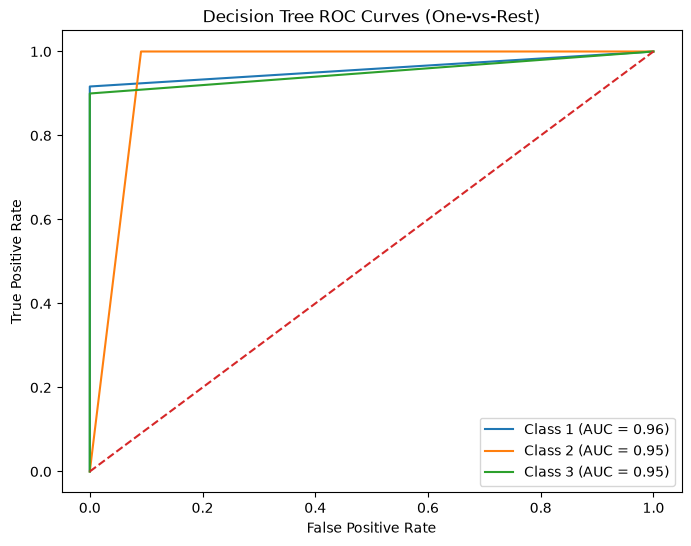

In [91]:
# Decision Tree Roc Curves (One-vs-Rest)
plt.figure(figsize=(8, 6))

for i, wine_class in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        dt_probabilities[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {wine_class} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

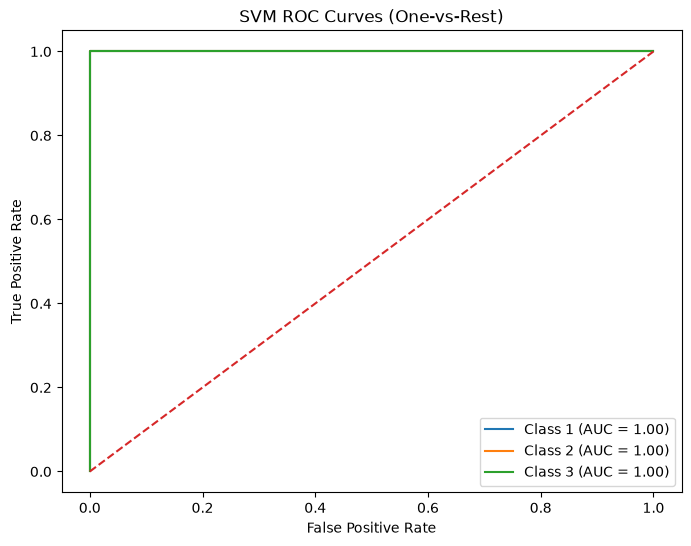

In [92]:
# SVM ROC curves (One-vs-Rest)
plt.figure(figsize=(8, 6))

for i, wine_class in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        svm_probabilities[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {wine_class} (AUC = {roc_auc:.2f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

# Model Comparison

The Decision Tree and Support Vector Machine were compared using accuracy, weighted precision, weighted recall and weighted F1-score.

The model with the higher test-set performance demonstrated a stronger ability to generalise to previously unseen wine observations. The confusion matrices were also examined to determine whether errors were concentrated in particular wine classes, while the ROC curves provided additional information about each model's ability to distinguish individual classes.
Differences in performance can be explained partly by the algorithms' underlying structures. A Decision Tree creates a sequence of threshold-based decisions and can capture non-linear relationships, but an unrestricted tree can overfit a relatively small training dataset.

The RBF SVM creates non-linear decision boundaries using multiple chemical properties simultaneously. Standardising the predictors is important for this model because SVM is sensitive to differences in feature scale.
However, the dataset contains only 178 observations. Therefore, performance on a single train-test split should be interpreted cautiously because different observations in the testing set could change the reported scores.

In [93]:
results_df = pd.DataFrame([
    dt_results,
    svm_results
])

results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.944444,0.951389,0.944444,0.944961
1,Support Vector Machine,0.972222,0.974074,0.972222,0.971970


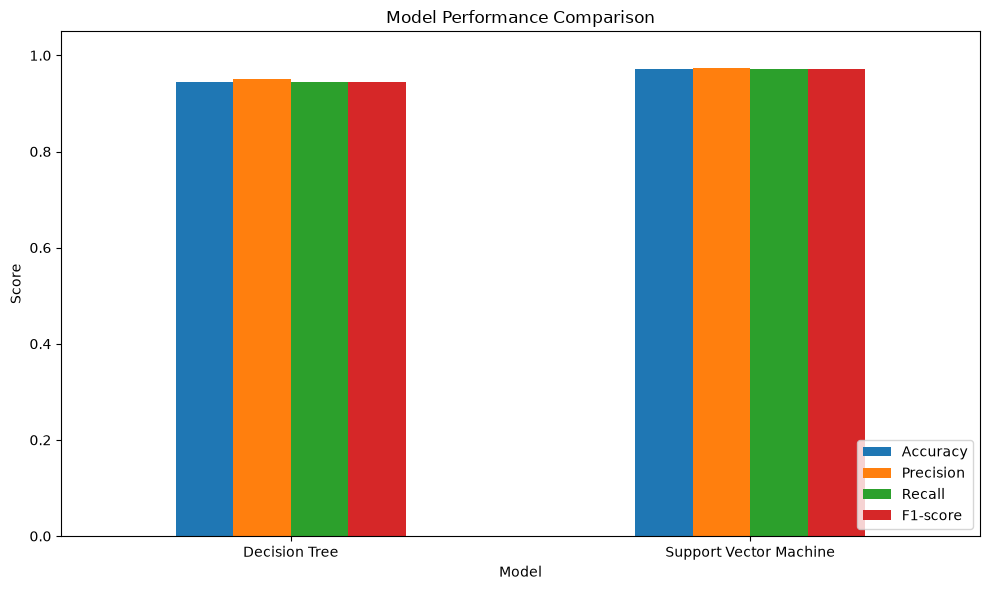

In [94]:
comparison = results_df.set_index("Model")

comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [95]:
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Highest test accuracy:")
print(best_model)

Highest test accuracy:
Model        Support Vector Machine
Accuracy                   0.972222
Precision                  0.974074
Recall                     0.972222
F1-score                    0.97197
Name: 1, dtype: object


### Decision Tree Feature Importance

The Decision Tree provides a built-in measure of feature importance based on how much each variable contributes to reducing impurity when splitting the data.
Features with larger importance values contributed more strongly to the tree's classification decisions.
However, these values should not automatically be interpreted as causal effects. They indicate how useful the variables were to this particular trained Decision Tree.

In [96]:
# decision tree feature importance
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

dt_importance

,Feature,Importance
6,Flavanoids,0.408073
9,Color.int,0.400189
12,Proline,0.110985
11,OD,0.020986
3,Acl,0.020865
2,Ash,0.020163
1,Malic.acid,0.018738
4,Mg,0.000000
0,Alcohol,0.000000
8,Proanth,0.000000


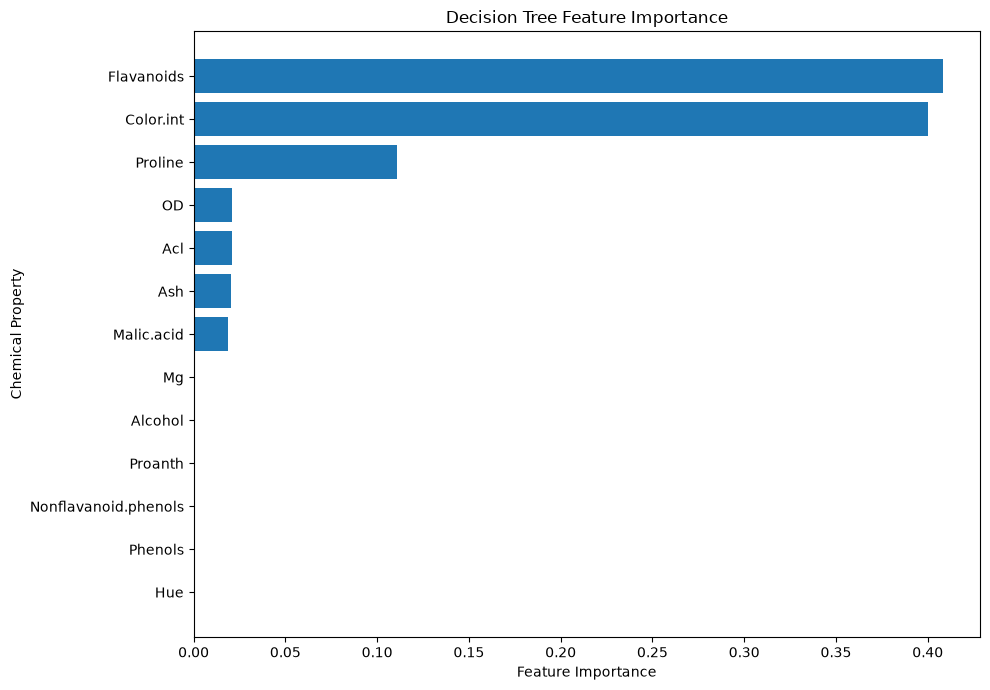

In [97]:
# Visualizing Decision Tree Feature Importance
plt.figure(figsize=(10, 7))

plt.barh(
    dt_importance["Feature"],
    dt_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Chemical Property")
plt.title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()

### Decision Tree Feature Importance

The Decision Tree identified **Flavanoids** and **Color Intensity** as the two most influential chemical properties, with importance scores of approximately **0.408** and **0.400**, respectively. Together, these two variables accounted for approximately 81% of the tree's total feature importance.
**Proline** was the third most important feature, with an importance of approximately **0.111**. OD and Alcalinity of Ash (Acl) contributed smaller amounts, with importance scores of approximately 0.021 each.

Several variables, including Alcohol, Magnesium, Proanthocyanins, Nonflavanoid Phenols, Phenols and Hue, received an importance score of zero. This does not mean that these chemical properties contain no useful information about wine class. It only means that this particular fitted Decision Tree did not use them when constructing its final decision rules.
The strong importance of Flavanoids, Color Intensity and Proline suggests that these properties provided particularly useful threshold splits for distinguishing between the three wine classes in the training data.


### SVM Feature Importance

Unlike a Decision Tree, an SVM with an RBF kernel does not provide a direct `feature_importances_` attribute.

Permutation importance was therefore used to estimate the contribution of each chemical property. This method measures how much model performance decreases when the values of one feature are randomly shuffled while the other features remain unchanged.
A larger decrease in accuracy suggests that the model relies more strongly on that feature for its predictions.
Permutation importance should still be interpreted carefully, particularly when predictors are correlated, because correlated variables may contain overlapping information.

In [98]:
svm_permutation = permutation_importance(
    svm_model,
    X_test_scaled,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

svm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": svm_permutation.importances_mean,
    "Std": svm_permutation.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

svm_importance

,Feature,Importance,Std
12,Proline,0.057407,0.023715
6,Flavanoids,0.050926,0.024931
11,OD,0.034259,0.024515
0,Alcohol,0.027778,0.026836
10,Hue,0.022222,0.020787
3,Acl,0.013889,0.021216
8,Proanth,0.010185,0.016795
5,Phenols,0.009259,0.013095
9,Color.int,0.008333,0.022850
7,Nonflavanoid.phenols,0.005556,0.013225


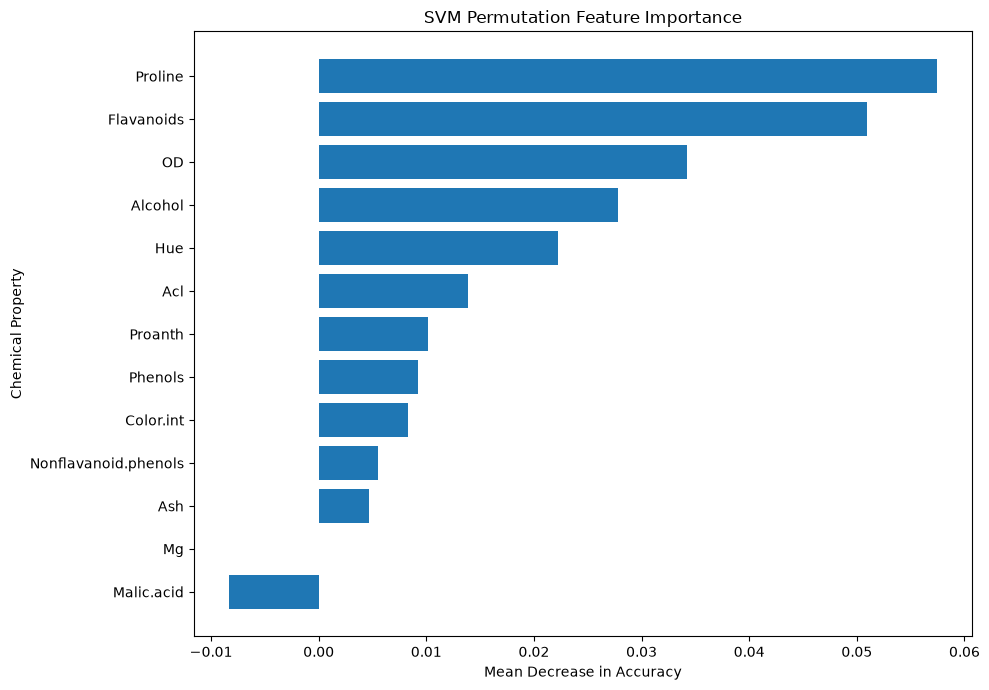

In [99]:

plt.figure(figsize=(10, 7))

plt.barh(
    svm_importance["Feature"],
    svm_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Mean Decrease in Accuracy")
plt.ylabel("Chemical Property")
plt.title("SVM Permutation Feature Importance")

plt.tight_layout()
plt.show()

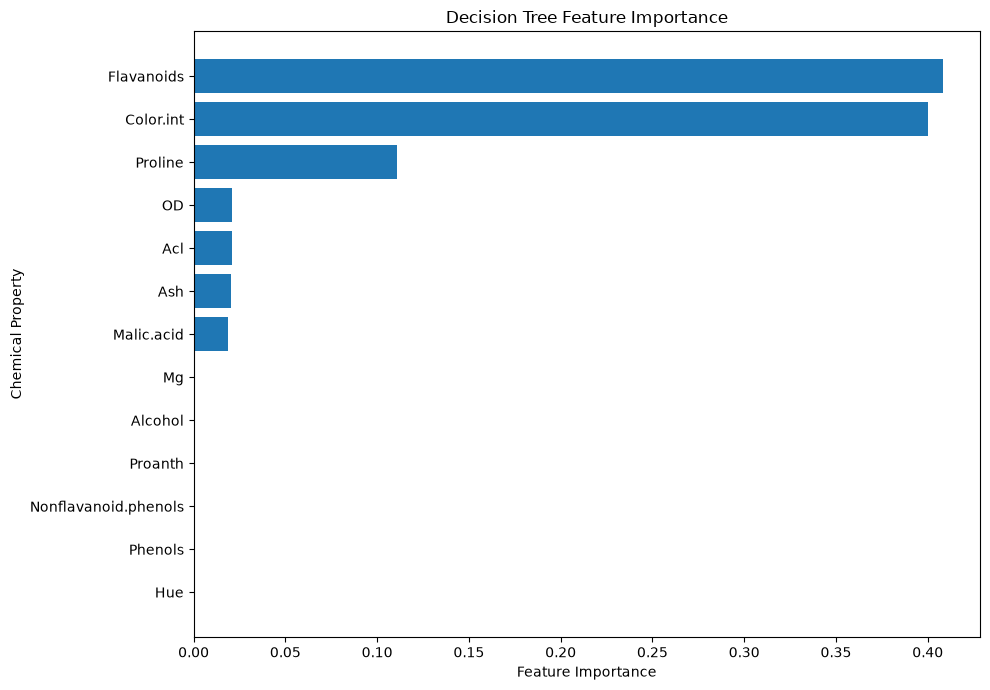

In [100]:
# Visualizing SVM Permutation Importance
plt.figure(figsize=(10, 7))

plt.barh(
    dt_importance["Feature"],
    dt_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Chemical Property")
plt.title("Decision Tree Feature Importance")

plt.tight_layout()
plt.show()

### SVM Permutation Feature Importance

Because an RBF Support Vector Machine does not provide a direct built-in `feature_importances_` measure, permutation importance was used to estimate the contribution of each chemical property.
**Proline** had the highest permutation importance, with a mean decrease in accuracy of approximately **0.0574** when its values were randomly shuffled. This was followed by **Flavanoids (0.0509)**, **OD (0.0343)**, **Alcohol (0.0278)** and **Hue (0.0222)**.

These results suggest that the SVM relied particularly on information contained in Proline and Flavanoids when distinguishing between wine classes.
Malic Acid produced a slightly negative permutation importance of approximately **-0.0083**. This should not be interpreted as evidence that Malic Acid is inherently harmful for wine classification. A small negative permutation importance can occur because of sampling variability, correlated predictors, or because shuffling the feature happens to produce slightly better predictions on a small test set.
The permutation importance estimates should therefore be interpreted cautiously, particularly because they were calculated using only 36 test observations.


## Interpretation of Important Chemical Properties

Comparing the feature-importance results from both models provides a more informative picture of which chemical properties contribute to wine classification.

The Decision Tree's five most important variables were **Flavanoids, Color Intensity, Proline, OD and Alcalinity of Ash**. The SVM's five most important variables according to permutation importance were **Proline, Flavanoids, OD, Alcohol and Hue**.
 Three variables therefore appeared among the five most important properties for **both models: Flavanoids, Proline and OD**. This agreement is notable because the Decision Tree and SVM use fundamentally different classification methods.

**Flavanoids** had the highest importance in the Decision Tree and the second-highest permutation importance for the SVM. **Proline** ranked third for the Decision Tree and first for the SVM. **OD** also appeared among the five most important features for both classifiers.
Color Intensity presents an interesting difference between the models. It was extremely important to the Decision Tree, with an importance score of approximately 0.400, but had a relatively small permutation importance for the SVM. This demonstrates that feature importance is model-dependent. The Decision Tree may rely heavily on a few individual threshold splits, whereas the RBF SVM can use complex combinations and interactions between several standardised features.

Overall, **Flavanoids, Proline and OD provide the most consistent evidence of predictive importance across the two classifiers used in this analysis**. However, these results describe predictive relationships and should not be interpreted as evidence that these chemical properties cause a wine to belong to a particular class.


In [101]:
# comparisons
print("Top 5 Decision Tree Features:")
display(dt_importance.head(5))

print("\nTop 5 SVM Features:")
display(svm_importance.head(5))

Top 5 Decision Tree Features:


,Feature,Importance
6,Flavanoids,0.408073
9,Color.int,0.400189
12,Proline,0.110985
11,OD,0.020986
3,Acl,0.020865



Top 5 SVM Features:


,Feature,Importance,Std
12,Proline,0.057407,0.023715
6,Flavanoids,0.050926,0.024931
11,OD,0.034259,0.024515
0,Alcohol,0.027778,0.026836
10,Hue,0.022222,0.020787


In [102]:
# common impotant features
top_dt = set(
    dt_importance.head(5)["Feature"]
)

top_svm = set(
    svm_importance.head(5)["Feature"]
)

common_features = top_dt.intersection(top_svm)

print("Features appearing in the top 5 for both models:")
print(common_features)

Features appearing in the top 5 for both models:
{'OD', 'Proline', 'Flavanoids'}


# Challenges and Limitations
Several limitations should be considered when interpreting the results.

1. Small Dataset
The dataset contains only 178 observations. This is relatively small for machine learning and means that model evaluation can be sensitive to the particular observations assigned to the training and testing sets.

2. Different Feature Scales
The chemical properties are measured using different numerical scales. This required standardisation for the SVM classifier. Failure to scale these variables could cause features with larger numerical magnitudes to disproportionately influence the model.

3. Risk of Overfitting
Decision Trees can overfit training data, particularly when their depth is unrestricted. Hyperparameter tuning or pruning could be used to control model complexity.

4. Hyperparameter Selection
The models in this analysis use mostly default hyperparameters. Their performance could potentially be improved using techniques such as GridSearchCV or RandomizedSearchCV.

5. Single Train-Test Split
Performance was evaluated using one 80:20 train-test split. Although stratification was used, a single split provides only one estimate of generalisation performance. Stratified k-fold cross-validation would provide a more robust estimate.

6. Feature Importance
Feature importance does not establish causation. Furthermore, correlated predictors may share similar information, which can affect both tree-based and permutation importance estimates.

## Potential Improvements
Future analysis could:
- Use stratified k-fold cross-validation.
- Perform hyperparameter optimisation.
- Prune or constrain the Decision Tree.
- Tune the SVM parameters such as `C` and `gamma`.
- Compare additional classifiers such as k-Nearest Neighbours, Random Forest or Naive Bayes.
- Investigate dimensionality reduction using Principal Component Analysis (PCA).
- Use cross-validated permutation importance for more stable feature-importance estimates.

# Conclusion

This analysis investigated whether the chemical properties of wines could be used to classify 178 samples into three wine classes using supervised machine learning.

Following data exploration and preprocessing, two classification algorithms were trained: a Decision Tree Classifier and a Support Vector Machine with an RBF kernel. Feature standardisation was applied for the SVM because the chemical properties were measured on substantially different numerical scales.
Both models achieved strong performance on the 36-observation test set. The Decision Tree achieved **94.44% accuracy**, while the SVM achieved **97.22% accuracy**. The SVM also achieved higher weighted precision (**97.41%**), recall (**97.22%**) and F1-score (**97.20%**) than the Decision Tree. Based on this test split, the SVM therefore demonstrated stronger classification performance.

The class-specific results showed that the SVM correctly classified all Class 1 observations and identified all Class 2 observations, while Class 3 had a recall of 0.90. Overall, the SVM made only one incorrect prediction among the 36 test observations, compared with two incorrect predictions by the Decision Tree.
Feature-importance analysis showed that the classifiers relied on the chemical properties differently. The Decision Tree relied particularly strongly on **Flavanoids** and **Color Intensity**, while permutation importance for the SVM ranked **Proline** and **Flavanoids** highest. Importantly, **Flavanoids, Proline and OD** appeared among the five most important features for both models, suggesting that these properties contain particularly useful information for distinguishing between the wine classes.

Although the SVM achieved the strongest results, the difference between the two models represents only one additional correct prediction on a relatively small test set. The results should therefore not be interpreted as definitive evidence that the SVM will always outperform the Decision Tree. Future analysis could use stratified k-fold cross-validation and hyperparameter tuning to obtain a more reliable estimate of model performance.
Overall, the analysis demonstrates that the chemical properties in the Wine dataset contain sufficient predictive information to classify the three wine classes with high accuracy and illustrates the complete machine learning classification workflow from data exploration and preprocessing through model evaluation, comparison and interpretation.
